In [1]:
%matplotlib widget
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from uncertainties import ufloat, unumpy as upy

from astropy.io import fits
from lmfit.models import GaussianModel, PolynomialModel
from lmfit.parameter import Parameter
import matplotlib.pyplot as plt
import numpy as np

In [2]:
names = ['J0020', 'J0136', 'J0203', 'J0243', 'J0333', 'J0404',
         'J2204', 'J2258', 'J2336', 'J0328', 'J0023']

lines = ['H_alpha', 'H_beta', 'H_gamma', 'H_delta', 'H_epsilon']

main_DIR = "/Users/javieratoro/Desktop/thesis/"
proj_DIR = f"{main_DIR}proyecto 2024-2/"

lines_or = pd.read_csv(f'{proj_DIR}CSV_files/emission_line1.csv')

# get data
all_comps = []
for name in names:
    fluxes = pd.read_csv(f'{proj_DIR}lines/magE2024_master_or.csv')

    for id in fluxes['ID'].values:
        if id[:5] == name:
            name_ = id

    save_path = (f'{proj_DIR}cont_subs/{name}/'
                    f'cont_corr_{name}.csv')

    if os.path.exists(save_path):
        print('Using MW dust + Balmer abs corrected and ' +
                'continuum substracted data')
        dcorr = pd.read_csv(save_path)
        arrays = dcorr.to_numpy().T
        wave, flux, _ = arrays
    else:
        save_path = f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/codes/{name}.fits'
        dcorr = fits.open(save_path)[1].data
        wave, flux, sigma = dcorr['wave'], dcorr['flux'], dcorr['sigma']

    comps = []
    for label in lines:
        wave_rest = lines_or[lines_or['name']==label]['vacuum_wave'].values[0]
        wave_obs = wave_rest * (1 + fluxes[fluxes['ID'] == name_]['z'].values[0])
        mask = ((wave > wave_obs - 20) & (wave < wave_obs + 20))
        wave_stamp, flux_stamp = wave[mask], flux[mask]
        sigma_stamp = dcorr['sigma'][mask]

        # model
        narrow_gaussian = GaussianModel(prefix=label+'_narrow_')
        broad_gaussian = GaussianModel(prefix=label+'_broad_')

        # Create a polynomial model for the continuum
        polydeg = 7
        polynomial = PolynomialModel(degree=polydeg)

        sum_of_gaussians = narrow_gaussian + broad_gaussian

        comp_mult = sum_of_gaussians + polynomial
        pars_mult = comp_mult.make_params()

        pars_mult.add(name='z', value=fluxes[fluxes['ID'] == name_]['z'].values[0], vary=False)

        pars_mult.add(name='sigma_v_narrow', value=30, min=20, max=50)
        pars_mult.add(name='sigma_v_broad', value=60, min=50, max=70)

        for param in ['center', 'amplitude', 'sigma']:
            narrow_key = f'{label}_narrow_{param}'
            if param == 'center':
                value = wave_rest
                vary = False
                expr = f'{wave_rest:6.2f}*(1+z)'
            elif param == 'amplitude':
                value = 1
                vary = True
                expr = None
            elif param == 'sigma':
                vary = True
                expr = f'(sigma_v_narrow/3e5)*{label}_narrow_center'
            pars_mult[narrow_key] = Parameter(name=narrow_key, value=value,
                                                vary=vary, expr=expr,
                                                min=0.0)


        for param in ['center', 'amplitude', 'sigma']:
            broad_key = f'{label}_broad_{param}'
            if param == 'center':
                value = wave_rest
                vary = False
                expr = f'{wave_rest:6.2f}*(1+z)'
            elif param == 'amplitude':
                value = 0.3
                vary = True
                expr = None
            elif param == 'sigma':
                vary = True
                expr = f'(sigma_v_broad/3e5)*{label}_broad_center'
            pars_mult[broad_key] = Parameter(name=broad_key,
                                                value=value, min=0.0,
                                                vary=vary, expr=expr)

        for i in range(polydeg+1):
            pars_mult[f'c{i:1.0f}'].set(value=0)

        out_comp_mult = comp_mult.fit(flux_stamp, pars_mult, x=wave_stamp,
                                        nan_policy='omit', max_nfev=1000)
        comps.append(out_comp_mult.eval_components(x=wave_stamp))
    all_comps.append(comps)

Using MW dust + Balmer abs corrected and continuum substracted data
Using MW dust + Balmer abs corrected and continuum substracted data
Using MW dust + Balmer abs corrected and continuum substracted data
Using MW dust + Balmer abs corrected and continuum substracted data
Using MW dust + Balmer abs corrected and continuum substracted data
Using MW dust + Balmer abs corrected and continuum substracted data
Using MW dust + Balmer abs corrected and continuum substracted data
Using MW dust + Balmer abs corrected and continuum substracted data
Using MW dust + Balmer abs corrected and continuum substracted data
Using MW dust + Balmer abs corrected and continuum substracted data
Using MW dust + Balmer abs corrected and continuum substracted data


In [3]:
name = 'J0404'
label = 'H_alpha'
DIR = '/Users/javieratoro/Desktop/thesis/proyecto 2024-2/'
EW_df = pd.read_csv(f'{DIR}bal_abs/{name}_EW_em.csv')
EW_df.loc[EW_df['name'] == label, 'EW_em'].values

array([168.15193522])

In [4]:
file_path = f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/{name}_EW.csv'
file_path[:-4]

'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/J0404_EW'

In [5]:
for name, all_comp in zip(names, all_comps):
    file_path = f'/Users/javieratoro/Desktop/thesis/proyecto 2024-2/bal_abs/J0404_EW.csv'
    if os.path.exists(file_path):
        res = pd.read_csv(file_path)
        for comp, label in zip(all_comp, lines):
            flux = np.max(comp[f'{label}_narrow_'] + comp[f'{label}_broad_'] + comp['polynomial'])
            cont = np.median(comp['polynomial'])
            EW = flux / cont
            if label == 'H_alpha':
                new_row = pd.DataFrame({'ID': res['ID'][0], 'z': res['ID'][0], 'name':label,
                                        'sigma': np.nan, 'EW':np.nan, 'EW_em': EW},index=[0])
                res = pd.concat([new_row, res], ignore_index=True)
            else:
                for id in fluxes['ID'].values:
                    if id[:5] == name:
                        name_ = id
                res.loc[(res['ID'] == name_) & (res['name'] == label), 'EW_em'] = EW
    else:
        continue

    res.to_csv(f'{file_path[:-4]}_em.csv')


In [38]:
import numpy as np
import pandas as pd
from uncertainties import unumpy as upy
from uncertainties import ufloat
# import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os


def save_catalog(galname, catalog, path):
    '''
    Function to save and/or update the emission line, equivalent width and
    velocity catalogs taken from the fluxes notebooks for each galaxy.
    '''

    catalog_exist = os.path.exists(path)
    if catalog_exist:
        print('Existent catalog (.csv) file.')

        catalog_all = pd.read_csv(path, on_bad_lines='skip')
        if np.sum(catalog_all['galname'] == galname) == 1:
            print('Existent data for ' + galname + ', overwriting...')
            index = np.where(catalog_all['galname'] == galname)[0][0]
            catalog_all.loc[index] = np.array(catalog.loc[0])
            catalog_all.to_csv(path, index=None)
            print('Done.')

        else:
            print('Non existent data for ' + galname + ', adding new data...')
            catalog.to_csv(path, mode='a',
                           header=False, index=None)
            print('Done.')
    else:
        print('File does not exist, creating new catalog...')
        catalog.to_csv(path, sep=',', index=None)
        print('Done.')


def k_cal(wl, Rv=3.1):
    """
    Calzetti extinction curve with Rv = 3.1. For an array of
    values of wavelength.

    Params
    ------
        wl : wavelength
        Rv : don't remember the name of this cosntant

    Output
    ------
        k : float value of the Calzetti curve at those wavelengths
    """

    wl_low = wl[wl < 6300]/1e4  # convert to um
    wl_high = wl[wl >= 6300]/1e4  # convert to um

    k_low = 2.659 * (-2.156 + (1.509 / wl_low) -
                     (0.198 / wl_low**2) + (0.011 / wl_low**3)) + Rv
    k_high = 2.659 * (-1.857 + 1.040 / wl_high) + Rv

    k = np.concatenate((k_low, k_high))
    return k


def residuals_balmer(params_balmer, x, data, uncertainty):

    slope = params_balmer['slope']
    # x = x_balmer[mask_balmer]
    model = x * (-slope)
    output = (model - data / uncertainty)

    return output


def linfunc(x, slope):
    return -1*x*slope


def E_BV_(name, fluxes):

    DIR = '/Users/javieratoro/Desktop/thesis/proyecto 2024-2/'
    lines = pd.read_csv(DIR + 'CSV_files/emission_line1.csv')

    Ha_w = lines[lines['name'] == 'H_alpha']['vacuum_wave'].values[0]
    Hb_w = lines[lines['name'] == 'H_beta']['vacuum_wave'].values[0]
    Hc_w = lines[lines['name'] == 'H_gamma']['vacuum_wave'].values[0]
    Hd_w = lines[lines['name'] == 'H_delta']['vacuum_wave'].values[0]

    x_balmer = np.array([k_cal(Ha_w) - k_cal(Hb_w),
                        k_cal(Hb_w) - k_cal(Hb_w),
                        k_cal(Hc_w) - k_cal(Hb_w),
                        k_cal(Hd_w) - k_cal(Hb_w)])

    Ha_flux = ufloat(np.mean(fluxes['H_alpha']),
                     np.std(fluxes['H_alpha']))

    Hb_flux = ufloat(np.mean(fluxes['H_beta']),
                     np.std(fluxes['H_beta']))

    Hc_flux = ufloat(np.mean(fluxes['H_gamma']),
                     np.std(fluxes['H_gamma']))

    Hd_flux = ufloat(np.mean(fluxes['H_delta']),
                     np.std(fluxes['H_delta']))
## add EW correction

    y_balmer = upy.log10([(Ha_flux / Hb_flux) / 2.86,
                          (Hb_flux / Hb_flux) / 1.0,
                          (Hc_flux / Hb_flux) / 0.464,
                          (Hd_flux / Hb_flux) / 0.256])
    mask_balmer = (y_balmer != 0)
    y = y_balmer[mask_balmer]
    x = np.asarray(x_balmer[mask_balmer]).flatten()

    popt, pcov = curve_fit(linfunc, x,
                           upy.nominal_values(y),
                           0.1, upy.std_devs(y))
    E_BV = popt[0]/0.4
    E_BV_ERR = np.sqrt(np.diag(pcov))[0]/0.4
    decrement_dict = {'galname': name,
                      'Ha/Hb': (Ha_flux / Hb_flux).nominal_value,
                      'Ha/Hb_err': (Ha_flux / Hb_flux).std_dev,
                      'Hg/Hb': (Hc_flux / Hb_flux).nominal_value,
                      'Hg/Hb_err': (Hc_flux / Hb_flux).std_dev,
                      'Hd/Hb': (Hd_flux / Hb_flux).nominal_value,
                      'Hd/Hb_err': (Hd_flux / Hb_flux).std_dev,
                      'E_BV': E_BV,
                      'E_BV_err': E_BV_ERR
                      }

    decrement_dict_pd = pd.DataFrame(data=decrement_dict, index=[0])
    save_catalog(name, decrement_dict_pd, DIR + '/results/bal_decrements_EW.csv')
    return E_BV, E_BV_ERR


def f_int(wl, line, E_BV):
    if type(wl) is not np.ndarray:
        wl = np.asarray(wl)
    return line * 10 ** (0.4 * E_BV * k_cal(wl))

In [6]:
def estimate_EW_absorption(EW_measured, name):

    DIR = '/Users/javieratoro/Desktop/thesis/proyecto 2024-2/'
    lines = pd.read_csv(DIR + 'CSV_files/emission_line1.csv')

    balmer_wavelengths = {
        'H_epsilon': lines.loc[lines['name'] == 'H_epsilon', 'vacuum_wave'].iloc[0],
        'H_delta':   lines.loc[lines['name'] == 'H_delta', 'vacuum_wave'].iloc[0],
        'H_gamma':   lines.loc[lines['name'] == 'H_gamma', 'vacuum_wave'].iloc[0],
        'H_beta':    lines.loc[lines['name'] == 'H_beta', 'vacuum_wave'].iloc[0],
        'H_alpha':   lines.loc[lines['name'] == 'H_alpha', 'vacuum_wave'].iloc[0]
    }

    # Only use measured ones
    lines_measured = list(EW_measured.keys())
    wl = np.array([balmer_wavelengths[line] for line in lines_measured])
    ew = np.array([EW_measured[line] for line in lines_measured])

    mask = ~np.isnan(ew) & ~np.isnan(wl)

    wl = wl[mask]
    ew = ew[mask]

    coeff = np.polyfit(wl, ew, 1)
    poly = np.poly1d(coeff)

    EW_pred = {}
    for line, λ in balmer_wavelengths.items():
        if EW_measured[line]:
            EW_pred[line] = poly(λ)
            print(f"{line}: predicted EW = {EW_pred[line]:.2f} (λ={λ})")
        else:
            EW_pred[line] = EW_measured[line]
            print(f"{line}: using measured EW = {EW_measured[line]:.2f}")
    plt.figure()
    for line, λ in balmer_wavelengths.items():
        if line=='H_alpha':
            plt.scatter(λ, EW_pred[line], color='red', label='extrapolated')
        else:
            plt.scatter(λ, EW_pred[line], color='red')
    plt.scatter(wl, ew, label='obs', color='blue')
    plt.legend()
    plt.title(name)
    plt.show()
    return EW_pred


def get_flux(name, line, EW_pred=None):
    DIR = '/Users/javieratoro/Desktop/thesis/proyecto 2024-2/'
    fluxes = pd.read_csv(DIR + f'lines/{name}_line_fluxes.csv')

    bright_lines = ['O2_3725', 'O2_3727', 'H_alpha', 'H_beta', 'H_gamma',
                    'O3_5008', 'O3_4959', 'N2_6550', 'N2_6585', 'S2_6716', 'S2_6730']
    auroral_lines = ['N2_5756', 'O1_6363', 'O3_4363', 'S3_6312', 'O2_7322', 'O2_7333']

    if line in auroral_lines:
        f_uncorr= fluxes[line + '_narrow_amplitude'].values + fluxes[line + '_broad_amplitude'].values
    else:
        f_uncorr = fluxes[line + '_narrow'].values
        if line in bright_lines:
            f_uncorr += fluxes[line + '_broad'].values

    # Apply absorption EW correction
    if EW_pred and line in EW_pred:
        EW_df = pd.read_csv(f'{DIR}bal_abs/{name}_EW_em.csv')
        EW_em = EW_df.loc[EW_df['name'] == label, 'EW_em'].values
        if isinstance(EW_em, np.ndarray):
            EW_em = EW_em[0]
        if not np.isnan(EW_em) and EW_em != 0:
            f_corr = f_uncorr * (1 + abs(EW_pred[line]) / abs(EW_em))
        else:
            print(f'No emission EW found for {line}, skipping correction.')

    return f_corr

def get_flux_normal(name, line):
    DIR = '/Users/javieratoro/Desktop/thesis/proyecto 2024-2/'

    bright_lines = ['O2_3725', 'O2_3727', 'H_alpha', 'H_beta',
                    'H_gamma', 'O3_5008', 'O3_4959', 'N2_6550',
                    'N2_6585', 'S2_6716', 'S2_6730']

    auroral_lines = ['N2_5756', 'O1_6363',
                     'O3_4363', 'S3_6312',
                     'O2_7322', 'O2_7333',
                     'O2_7322_7333']

    fluxes = pd.read_csv(DIR + f'lines/{name}_line_fluxes.csv')

    if line in auroral_lines:
        narrow_ = fluxes[line + '_narrow_amplitude'].values
        broad_ = fluxes[line + '_broad_amplitude'].values
        flux = narrow_ + broad_
    else:
        narrow = fluxes[line + '_narrow'].values
        flux = narrow
        if line in bright_lines:
            broad = fluxes[line + '_broad'].values
            flux += broad

    return flux

def save_fluxes():
    DIR = '/Users/javieratoro/Desktop/thesis/proyecto 2024-2/'
    lines = pd.read_csv(DIR + 'CSV_files/emission_line1.csv')
    names = ['J0020', 'J0203', 'J0243','J0333', 'J0404',
             'J2204', 'J2258', 'J2336', 'J0328']


    lines_H = ['H_alpha', 'H_beta', 'H_gamma', 'H_delta', 'H_epsilon']

    columns_ = ['ID', 'mass', 'z'] + [col for line in lines['name']
                                      for col in (f"{line}_flux", f"{line}_fluxerr")]
    df = pd.DataFrame(columns=columns_)

    for name in names:
        print(f'\nProcessing {name}...')
        EW_data = pd.read_csv(DIR + f'bal_abs/{name}_EW_em.csv')
        EW_measured = dict(zip(EW_data['name'][:5], -1 * EW_data['EW'][:5]))
        EW_pred = estimate_EW_absorption(EW_measured, name)

        data = pd.read_csv(DIR + f'lines/{name}/{name}_model.csv')
        all_rows = {'ID': data['ID'][0], 'mass': data['mass'][0], 'z': data['z'][0]}

        fluxes = {}
        for line in lines_H:
            wl = lines.loc[lines['name'] == line, 'vacuum_wave'].values
            flux = get_flux(name, line, EW_pred)
            fluxes[line] = flux
            fluxes[f'{line}_wave'] = wl

        E_BV, _ = E_BV_(name, fluxes)
        for line in lines['name']:
            if line in lines_H:
                wl, flux = fluxes[f'{line}_wave'], fluxes[line]
            else:
                wl = lines[lines['name'] == line]['vacuum_wave'].values
                flux = get_flux_normal(name, line)
            f_corr = f_int(wl, flux, E_BV)
            all_rows[f"{line}_flux"] = np.median(f_corr)
            all_rows[f"{line}_fluxerr"] = np.std(f_corr)


        df.loc[len(df)] = all_rows
    file_path = f'{DIR}lines/magE2024_master_EWcorr.csv'
    print(df)
    df.to_csv(file_path)



Processing J0020...
H_epsilon: predicted EW = 5.73 (λ=3971.2)
H_delta: predicted EW = 5.67 (λ=4102.89)
H_gamma: predicted EW = 5.54 (λ=4341.68)
H_beta: predicted EW = 5.27 (λ=4862.69)
H_alpha: predicted EW = 4.38 (λ=6564.58)


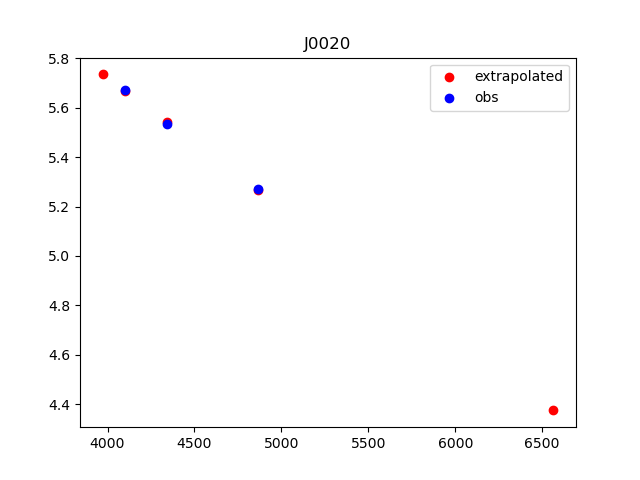

NameError: name 'E_BV_' is not defined

In [14]:
save_fluxes()

In [8]:
EWcorr= pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/magE2024_master_EWcorr.csv')
Dcorr = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/magE2024_master_Dcorr.csv')
EWbal= pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/results/bal_decrements_EW.csv')
Dbal = pd.read_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/results/bal_decrements.csv')

In [9]:
EWcorr = EWcorr.sort_values(by='ID')
EWbal = EWbal.sort_values(by='galname')

In [10]:
Dcorr = Dcorr[2:].sort_values(by='ID')
Dbal = Dbal[2:].sort_values(by='galname')

In [11]:
EWbal

,galname,Ha/Hb,Ha/Hb_err,Hg/Hb,Hg/Hb_err,Hd/Hb,Hd/Hb_err,E_BV,E_BV_err
0,J0020,4.095049,0.022072,0.416686,0.002861,0.171769,0.002601,0.308921,0.032042
1,J0203,3.913542,0.020145,0.348127,0.004301,0.151102,0.002616,0.291522,0.067111
2,J0243,3.623967,0.017509,0.423652,0.003127,0.223055,0.002636,0.200361,0.003345
7,J0328,4.369795,0.013492,0.365604,0.002151,0.161998,0.001447,0.378703,0.033564
3,J0333,3.482577,0.012862,0.384025,0.002062,0.193456,0.001523,0.199369,0.053965
8,J0404,3.679497,0.027598,0.375565,0.007782,0.195974,0.004311,0.226121,0.030453
4,J2204,3.480362,0.017359,0.385526,0.003526,0.182593,0.002436,0.192015,0.043898
5,J2258,3.901464,0.031993,0.474302,0.005110,0.236460,0.003999,0.227092,0.065169
6,J2336,3.500163,0.011671,0.383127,0.002416,0.180916,0.001815,0.194161,0.042009


In [12]:
Dbal

,galname,Ha/Hb,Ha/Hb_err,Hg/Hb,Hg/Hb_err,Hd/Hb,Hd/Hb_err,E_BV,E_BV_err
2,J0020,4.263558,0.022981,0.411704,0.002827,0.168791,0.002556,0.342013,0.038934
3,J0203,3.938596,0.020274,0.347450,0.004293,0.150674,0.002609,0.296878,0.066857
4,J0243,3.659304,0.017679,0.422403,0.003118,0.222098,0.002624,0.208365,0.003166
10,J0328,4.177213,0.012898,0.370838,0.002182,0.165402,0.001478,0.341053,0.035065
5,J0333,3.493540,0.012903,0.383656,0.002060,0.193185,0.001521,0.201946,0.043912
6,J0404,3.526026,0.026447,0.380636,0.007887,0.199858,0.004397,0.190341,0.032019
7,J2204,3.399922,0.016958,0.377425,0.003452,0.177051,0.002362,0.178062,0.054437
8,J2258,3.811617,0.031256,0.477750,0.005147,0.238975,0.004042,0.208038,0.063921
9,J2336,3.470984,0.011574,0.384115,0.002422,0.181597,0.001822,0.187175,0.042315


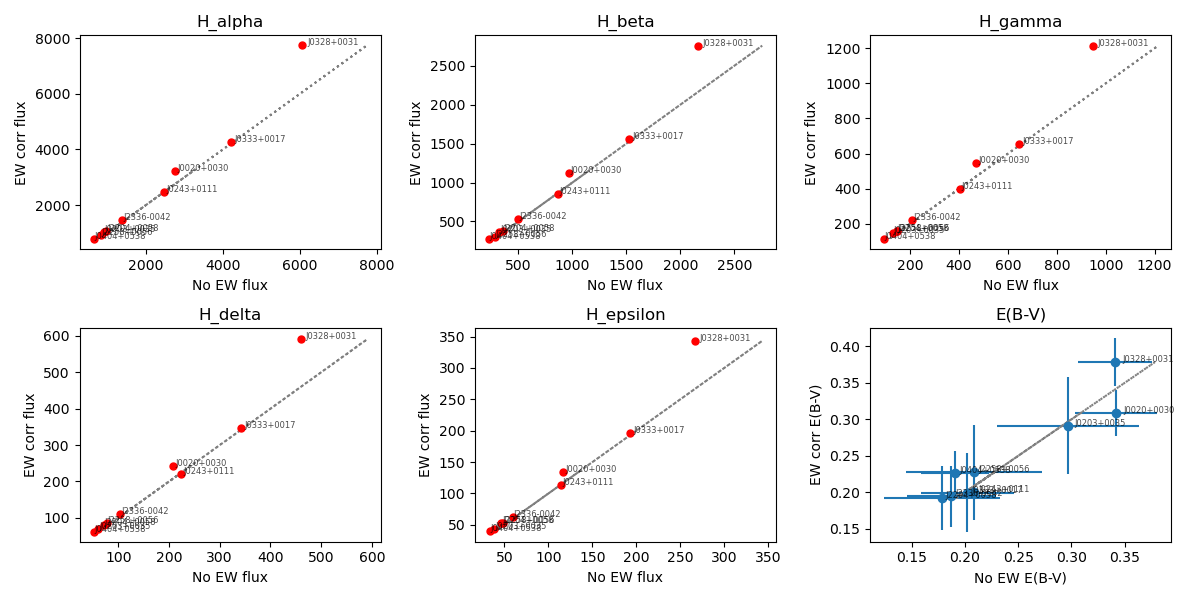

In [13]:
lines = pd.read_csv(DIR + 'CSV_files/emission_line1.csv')

names = ['J0020', 'J0203', 'J0243','J0333',
         'J2204', 'J2258', 'J2336', 'J0328']

lines_H = ['H_alpha', 'H_beta', 'H_gamma', 'H_delta', 'H_epsilon']


fig, axs = plt.subplots(2,3, figsize=(12,6))
i, j = 0 , 0
for line in lines_H:
        if j == 3:
            i += 1
            j = 0
        x = Dcorr[f'{line}_flux']
        y = EWcorr[f'{line}_flux']
        axs[i, j].errorbar(x, y, xerr=Dcorr[f'{line}_fluxerr'],
                          yerr=EWcorr[f'{line}_fluxerr'], fmt='o', ms=5,
                           color='red')

        for xi, yi, name in zip(x, y, Dcorr['ID']):
            axs[i, j].text(
                xi * 1.02, yi,  # a little offset in x for readability
                name,
                fontsize=6,
                color='black',
                alpha=0.7
            )

        axs[i, j].plot(EWcorr[f'{line}_flux'],
                       EWcorr[f'{line}_flux'], ls='dotted', color='grey')
        axs[i, j].set_title(line)
        axs[i ,j].set_xlabel('No EW flux')
        axs[i ,j].set_ylabel('EW corr flux')
        j += 1
x, y = Dbal['E_BV'], EWbal['E_BV']
axs[-1,-1].errorbar(x, y,
                    xerr=Dbal['E_BV_err'], yerr=EWbal['E_BV_err'], fmt='o')
for xi, yi, name in zip(x, y, Dcorr['ID']):
    axs[-1, -1].text(
        xi * 1.02, yi,
        name,
        fontsize=6,
        color='black',
        alpha=0.7
    )
axs[-1, -1].plot(EWbal['E_BV'], EWbal['E_BV'], ls='dotted', color='grey')
axs[-1, -1].set_title('E(B-V)')
axs[-1 ,-1].set_xlabel('No EW E(B-V)')
axs[-1 ,-1].set_ylabel('EW corr E(B-V)')
plt.tight_layout()
plt.show()

In [58]:

first_2_row = Dcorr.iloc[:2].copy()

In [459]:
# Append to df2

df2 = pd.concat([EWcorr, first_2_row], ignore_index=True)
df2.to_csv('/Users/javieratoro/Desktop/thesis/proyecto 2024-2/lines/magE2024_master.csv')